SALES FORECASTING DATA GENERATION
================================================================================

Company: GlobalMart Retail (Fictitious)
Business: International E-commerce Platform
Market: Operating in North America, Europe, and Asia

PURPOSE:
Generate realistic monthly sales data for a 3-year period (2022-2024) that
will be used for time series forecasting.

WHAT THIS CREATES:
- 36 months of historical sales data
- Realistic trends (growth over time)
- Seasonal patterns (holiday spikes, summer dips)
- Random fluctuations (normal business variance)

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

print("="*70)
print("GLOBALMART RETAIL - SALES DATA GENERATION")
print("="*70)
print("\nCompany: GlobalMart Retail")
print("Business: International E-commerce Platform")
print("Markets: North America, Europe, Asia")
print("Period: January 2023 - December 2025 (36 months)")
print("="*70)

GLOBALMART RETAIL - SALES DATA GENERATION

Company: GlobalMart Retail
Business: International E-commerce Platform
Markets: North America, Europe, Asia
Period: January 2023 - December 2025 (36 months)


In [ ]:
# STEP 1: CREATE DATE RANGE

print("\n\nSTEP 1: Creating date range...")

# Start date: January 1, 2023
start_date = datetime(2023, 1, 1)

# Create 36 months (3 years)
months = 36

# Generate monthly dates
dates = pd.date_range(start=start_date, periods=months, freq='MS')  # MS = Month Start

print(f"✓ Created {months} months from {dates[0].date()} to {dates[-1].date()}")



STEP 1: Creating date range...
✓ Created 36 months from 2023-01-31 to 2025-12-31


In [5]:
# STEP 2: CREATE BASE SALES TREND


# Base monthly revenue starts at $2M and grows over time
# This represents business growth (more customers, market expansion)
base_revenue = 2000000  # $2 million starting point

# Growth rate: 3% per month (realistic for growing e-commerce)
monthly_growth_rate = 0.03

# Calculate trend component
# Each month is slightly higher than the previous month
trend = [base_revenue * (1 + monthly_growth_rate) ** i for i in range(months)]

print(f"✓ Base revenue: ${base_revenue:,.0f}")
print(f"✓ Monthly growth rate: {monthly_growth_rate*100}%")
print(f"✓ Revenue by month 36: ${trend[-1]:,.0f}")

✓ Base revenue: $2,000,000
✓ Monthly growth rate: 3.0%
✓ Revenue by month 36: $5,627,725


In [6]:
# STEP 3: ADD SEASONAL PATTERNS

# E-commerce has strong seasonal patterns:
# - High sales in November (Black Friday), December (Christmas)
# - Moderate sales in January (New Year sales)
# - Lower sales in summer (July-August)
# - Back-to-school bump in September

# Create seasonal multipliers for each month
seasonal_pattern = {
    1: 1.05,   # January - New Year sales
    2: 0.95,   # February - Post-holiday dip
    3: 1.00,   # March - Normal
    4: 1.00,   # April - Normal
    5: 0.98,   # May - Slight dip
    6: 0.95,   # June - Summer starts
    7: 0.90,   # July - Summer low
    8: 0.92,   # August - Still summer
    9: 1.05,   # September - Back to school
    10: 1.10,  # October - Pre-holiday
    11: 1.35,  # November - Black Friday!
    12: 1.40   # December - Christmas!
}

# Apply seasonal pattern to each month
seasonality = []
for date in dates:
    month = date.month
    seasonality.append(seasonal_pattern[month])

print(f"✓ Added seasonal multipliers")
print(f"  - Peak season: November ({seasonal_pattern[11]}x), December ({seasonal_pattern[12]}x)")
print(f"  - Low season: July ({seasonal_pattern[7]}x), August ({seasonal_pattern[8]}x)")

✓ Added seasonal multipliers
  - Peak season: November (1.35x), December (1.4x)
  - Low season: July (0.9x), August (0.92x)


In [7]:
# STEP 4: ADD RANDOM FLUCTUATIONS

print("\n\nSTEP 4: Adding random business fluctuations...")

# Real business has random variations:
# - Marketing campaigns
# - Competitor actions
# - Economic factors
# - Supply chain issues

# Add random noise (±10% variation)
np.random.seed(42)
noise = np.random.normal(1.0, 0.10, months)  # Mean=1.0, StdDev=0.10

print(f"✓ Added random fluctuations (±10% variance)")



STEP 4: Adding random business fluctuations...
✓ Added random fluctuations (±10% variance)


In [8]:
# STEP 5: CALCULATE FINAL SALES

print("\n\nSTEP 5: Calculating final monthly sales...")

# Final Sales = Trend × Seasonality × Random Noise
sales = []
for i in range(months):
    monthly_sales = trend[i] * seasonality[i] * noise[i]
    sales.append(monthly_sales)

# Create DataFrame
df = pd.DataFrame({
    'date': dates,
    'sales': sales
})

# Add additional columns for analysis
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')
df['quarter'] = df['date'].dt.quarter

# Round sales to nearest dollar
df['sales'] = df['sales'].round(2)

print(f"✓ Generated sales data for {len(df)} months")
print(f"✓ Average monthly sales: ${df['sales'].mean():,.0f}")
print(f"✓ Minimum monthly sales: ${df['sales'].min():,.0f}")
print(f"✓ Maximum monthly sales: ${df['sales'].max():,.0f}")



STEP 5: Calculating final monthly sales...
✓ Generated sales data for 36 months
✓ Average monthly sales: $3,657,473
✓ Minimum monthly sales: $1,929,942
✓ Maximum monthly sales: $7,982,865


In [9]:
# STEP 6: SAVE DATA TO CSV

print("\n\nSTEP 6: Saving data to CSV file...")

output_file = 'globalmart_sales_data.csv'
df.to_csv(output_file, index=False)

print(f"✓ Data saved to: globalmart_sales_data.csv")
print(f"✓ Total records: {len(df)}")



STEP 6: Saving data to CSV file...
✓ Data saved to: globalmart_sales_data.csv
✓ Total records: 36


In [11]:
# STEP 7: SHOW SAMPLE DATA

print("\n\n" + "="*70)
print("SAMPLE DATA (First 12 months)")
print("="*70)
print(df.head(12)[['date', 'month_name', 'sales', 'year', 'quarter']].to_string(index=False))

print("\n\n" + "="*70)
print("YEARLY SUMMARY")
print("="*70)
yearly_summary = df.groupby('year')['sales'].agg(['sum', 'mean', 'min', 'max'])
yearly_summary.columns = ['Total_Sales', 'Avg_Monthly_Sales', 'Min_Month', 'Max_Month']
yearly_summary['Total_Sales'] = yearly_summary['Total_Sales'].apply(lambda x: f'${x:,.0f}')
yearly_summary['Avg_Monthly_Sales'] = yearly_summary['Avg_Monthly_Sales'].apply(lambda x: f'${x:,.0f}')
yearly_summary['Min_Month'] = yearly_summary['Min_Month'].apply(lambda x: f'${x:,.0f}')
yearly_summary['Max_Month'] = yearly_summary['Max_Month'].apply(lambda x: f'${x:,.0f}')
print(yearly_summary)




SAMPLE DATA (First 12 months)
      date month_name      sales  year  quarter
2023-01-31    January 2204309.97  2023        1
2023-02-28   February 1929941.68  2023        1
2023-03-31      March 2259226.55  2023        1
2023-04-30      April 2518305.17  2023        2
2023-05-31        May 2154343.10  2023        2
2023-06-30       June 2151049.25  2023        2
2023-07-31       July 2488713.42  2023        3
2023-08-31     August 2436635.93  2023        3
2023-09-30  September 2535326.79  2023        3
2023-10-31    October 3026242.92  2023        4
2023-11-30   November 3460419.67  2023        4
2023-12-31   December 3695344.75  2023        4


YEARLY SUMMARY
      Total_Sales Avg_Monthly_Sales   Min_Month   Max_Month
year                                                       
2023  $30,859,859        $2,571,655  $1,929,942  $3,695,345
2024  $40,685,781        $3,390,482  $2,256,368  $5,208,415
2025  $60,123,396        $5,010,283  $3,816,738  $7,982,865




STEP 8: Creating visualization...


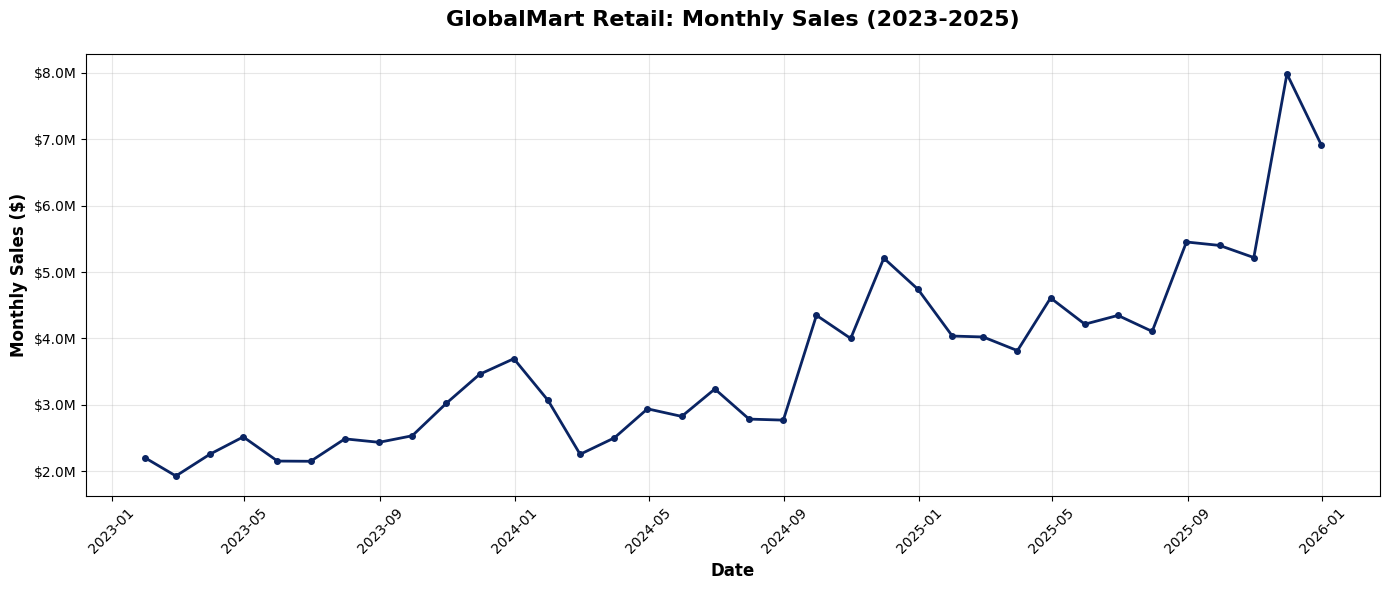

In [12]:
# STEP 8: CREATE VISUALIZATION

print("\n\nSTEP 8: Creating visualization...")

plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['sales'], marker='o', linewidth=2, markersize=4, color='#0A2463')
plt.title('GlobalMart Retail: Monthly Sales (2023-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Monthly Sales ($)', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

# Format y-axis to show millions
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('globalmart_sales_trend.png', dpi=300, bbox_inches='tight');